# Promoter Classification Notebook

Notebook ini memperlihatkan pipeline inti proyek secara end-to-end: kode training model ditulis langsung di notebook, tetapi tetap memakai helper Python dari folder `src/` agar rapi dan reusable.

Objektif model:

- Input: DNA sequence string
- Output: promoter classification
  - `0 = non-promoter`
  - `1 = promoter`

Dataset utama:

- `InstaDeepAI/nucleotide_transformer_downstream_tasks_revised`
- Task: `promoter_all`

Tidak ada synthetic fallback. Jika dataset real gagal dimuat atau divalidasi, notebook harus berhenti.

## 1. Setup Path dan Konstanta

In [1]:
from pathlib import Path
import json
import os
import sys
from datetime import datetime, timezone

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Repository root:", ROOT)

Repository root: c:\Users\nazwa\Coding\Semester-6\KDS-Sekuens-DNA-RNA


In [2]:
DATASET_NAME = "InstaDeepAI/nucleotide_transformer_downstream_tasks_revised"
TASK_NAME = "promoter_all"

PROCESSED_DIR = Path("data/processed")
TRAIN_CSV = PROCESSED_DIR / "promoter_all_train.csv"
TEST_CSV = PROCESSED_DIR / "promoter_all_test.csv"

MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "promoter_kmer_logreg.joblib"
VECTORIZER_PATH = MODEL_DIR / "promoter_kmer_vectorizer.joblib"
METADATA_PATH = MODEL_DIR / "promoter_kmer_metadata.json"

REPORT_DIR = Path("reports/evaluation")
METRICS_PATH = REPORT_DIR / "metrics.json"
REPORT_PATH = REPORT_DIR / "classification_report.txt"
CONFUSION_MATRIX_PATH = REPORT_DIR / "confusion_matrix.png"

K = 6
RANDOM_STATE = 42

## 2. Download dan Filter Dataset Real

Cell ini memperlihatkan proses dataset secara eksplisit menggunakan Hugging Face `datasets`:

1. Load dataset real.
2. Ambil official `train` dan `test` split.
3. Filter `task == "promoter_all"`.
4. Validasi dan simpan CSV.

In [3]:
import pandas as pd
from datasets import load_dataset

from dna_rna_classifier.promoter_dataset import (
    LABEL_MAPPING,
    REQUIRED_COLUMNS,
    validate_promoter_dataframe,
    read_promoter_csv,
)

HF_CACHE_DIR = ROOT / ".cache" / "huggingface"
os.environ.setdefault("HF_HOME", str(HF_CACHE_DIR))
os.environ.setdefault("HF_HUB_CACHE", str(HF_CACHE_DIR / "hub"))
os.environ.setdefault("HF_DATASETS_CACHE", str(HF_CACHE_DIR / "datasets"))

dataset_dict = load_dataset(DATASET_NAME, cache_dir=str(HF_CACHE_DIR))
dataset_dict

c:\Users\nazwa\.pyenv\pyenv-win\versions\3.13.3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 493242
    })
    test: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 38822
    })
})

In [4]:
train_raw = dataset_dict["train"].filter(lambda example: example["task"] == TASK_NAME)
test_raw = dataset_dict["test"].filter(lambda example: example["task"] == TASK_NAME)

train_df = validate_promoter_dataframe(train_raw.to_pandas(), task=TASK_NAME)
test_df = validate_promoter_dataframe(test_raw.to_pandas(), task=TASK_NAME)

assert list(train_df.columns) == REQUIRED_COLUMNS
assert list(test_df.columns) == REQUIRED_COLUMNS
assert not train_df.empty
assert not test_df.empty

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Train label distribution:", train_df["label"].value_counts().sort_index().to_dict())
print("Test label distribution:", test_df["label"].value_counts().sort_index().to_dict())
train_df.head()

Filter: 100%|██████████| 38822/38822 [00:00<00:00, 205107.91 examples/s]


Train: (30000, 4)
Test: (1584, 4)
Train label distribution: {0: 14950, 1: 15050}
Test label distribution: {0: 792, 1: 792}


,sequence,label,task,name
0,TCATCTTCTGTTTTTGTTGCACTGTGTTCTCAGAATGTGTTTGGTA...,0,promoter_all,chr1:87378000-87378300|0
1,GGCTTGGAGGTTAAGAAAATGGCCCCACAACCCACAGCAATAAATA...,0,promoter_all,chr17:73594000-73594300|0
2,CCAAGGGATGATTTCAGGGGGAGCTCTGCAGACCCAGTGTTCCAGG...,0,promoter_all,chr9:87333000-87333300|0
3,CTTTTCAAATGTTTTTTCATCCTTCATGTAAGTCACAGGACACTGC...,0,promoter_all,chr3:102501000-102501300|0
4,AACTCGCAGCTGCGGAGCGACCCCACGCGCACGGCCCCTTCCGCAG...,1,promoter_all,chr9:135699468-135699768|1


## 3. Feature Extraction k-mer

Di sini terlihat representasi komputasional utama: DNA diubah menjadi token k-mer, lalu dihitung dengan `CountVectorizer`.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

from dna_rna_classifier.modeling import KmerTokenizer

tokenizer = KmerTokenizer(k=K)
example_sequence = train_df.iloc[0]["sequence"]

print("Example sequence length:", len(example_sequence))
print("First 10 k-mers:", tokenizer(example_sequence)[:10])

Example sequence length: 300
First 10 k-mers: ['TCATCT', 'CATCTT', 'ATCTTC', 'TCTTCT', 'CTTCTG', 'TTCTGT', 'TCTGTT', 'CTGTTT', 'TGTTTT', 'GTTTTT']


In [6]:
vectorizer = CountVectorizer(analyzer=KmerTokenizer(k=K), lowercase=False)

X_train = vectorizer.fit_transform(train_df["sequence"])
y_train = train_df["label"].astype(int)

X_test = vectorizer.transform(test_df["sequence"])
y_test = test_df["label"].astype(int)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

X_train shape: (30000, 4096)
X_test shape: (1584, 4096)
Vocabulary size: 4096


## 4. Train Logistic Regression

Bagian ini adalah training model secara eksplisit menggunakan k-mer feature extraction dan Logistic Regression.

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

print("Classes:", model.classes_)

Classes: [0 1]


## 5. Evaluate on Official Test Split

Evaluasi dilakukan pada `promoter_all_test.csv`, bukan data sintetis.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

y_pred = model.predict(X_test)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="binary",
    pos_label=1,
    zero_division=0,
)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
report_text = classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["non-promoter", "promoter"],
    zero_division=0,
)

print("accuracy:", round(accuracy, 4))
print("precision:", round(precision, 4))
print("recall:", round(recall, 4))
print("f1_score:", round(f1, 4))
print("confusion matrix:\n", cm)
print(report_text)

accuracy: 0.8359
precision: 0.835
recall: 0.8371
f1_score: 0.8361
confusion matrix:
 [[661 131]
 [129 663]]
              precision    recall  f1-score   support

non-promoter       0.84      0.83      0.84       792
    promoter       0.84      0.84      0.84       792

    accuracy                           0.84      1584
   macro avg       0.84      0.84      0.84      1584
weighted avg       0.84      0.84      0.84      1584



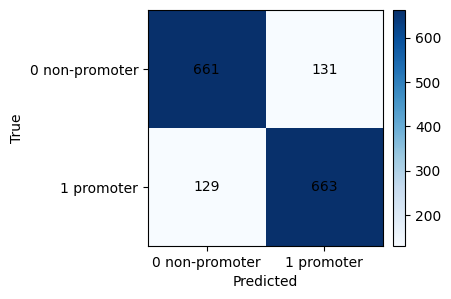

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 4))
image = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["0 non-promoter", "1 promoter"])
ax.set_yticks([0, 1], labels=["0 non-promoter", "1 promoter"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for row_index in range(cm.shape[0]):
    for col_index in range(cm.shape[1]):
        ax.text(col_index, row_index, str(cm[row_index, col_index]), ha="center", va="center")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 6. Save Model, Vectorizer, Metadata, and Evaluation Report

Artifact ini dipakai oleh Streamlit app.

In [10]:
import joblib

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODEL_PATH)
joblib.dump(vectorizer, VECTORIZER_PATH)

metadata = {
    "dataset_name": DATASET_NAME,
    "task_name": TASK_NAME,
    "training_csv_path": str(TRAIN_CSV),
    "number_of_training_samples": int(len(train_df)),
    "kmer_size": K,
    "model_type": "logistic_regression",
    "label_mapping": {str(key): value for key, value in LABEL_MAPPING.items()},
    "created_timestamp": datetime.now(timezone.utc).isoformat(),
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

metrics = {
    "dataset": DATASET_NAME,
    "task": TASK_NAME,
    "test_csv_path": str(TEST_CSV),
    "number_of_test_samples": int(len(test_df)),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "confusion_matrix": cm.tolist(),
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
REPORT_PATH.write_text(report_text, encoding="utf-8")
fig.savefig(CONFUSION_MATRIX_PATH, dpi=180)

print("Saved model:", MODEL_PATH)
print("Saved vectorizer:", VECTORIZER_PATH)
print("Saved metadata:", METADATA_PATH)
print("Saved metrics:", METRICS_PATH)
print("Saved report:", REPORT_PATH)
print("Saved confusion matrix:", CONFUSION_MATRIX_PATH)

Saved model: models\promoter_kmer_logreg.joblib
Saved vectorizer: models\promoter_kmer_vectorizer.joblib
Saved metadata: models\promoter_kmer_metadata.json
Saved metrics: reports\evaluation\metrics.json
Saved report: reports\evaluation\classification_report.txt
Saved confusion matrix: reports\evaluation\confusion_matrix.png


## 7. Predict One Real Test Sequence

Contoh input diambil dari official test split, bukan sequence buatan.

In [11]:
sample = test_df.sample(1, random_state=RANDOM_STATE).iloc[0]
sample_features = vectorizer.transform([sample["sequence"]])
sample_prediction = int(model.predict(sample_features)[0])

result = {
    "name": sample["name"],
    "task": sample["task"],
    "true_label": int(sample["label"]),
    "predicted_label": sample_prediction,
    "predicted_meaning": LABEL_MAPPING.get(sample_prediction),
    "sequence_length": len(sample["sequence"]),
}

if hasattr(model, "predict_proba"):
    probabilities = model.predict_proba(sample_features)[0]
    result["probabilities"] = {
        str(int(label)): float(probability)
        for label, probability in zip(model.classes_, probabilities)
    }

result

{'name': 'chr20:50081605-50081905|1',
 'task': 'promoter_all',
 'true_label': 1,
 'predicted_label': 0,
 'predicted_meaning': 'non-promoter',
 'sequence_length': 300,
 'probabilities': {'0': 0.9661177674312877, '1': 0.03388223256871226}}

## 8. Biological Feature Snapshot

Bagian ini menghubungkan model komputasional dengan analisis biologis sederhana dari sequence yang sama.

In [12]:
from dna_rna_classifier.features import sequence_feature_summary, top_kmers
from dna_rna_classifier.central_dogma import find_orfs

sequence = sample["sequence"]
sequence_feature_summary(sequence, k=K)

{'sequence_type': 'DNA',
 'length': 300,
 'counts': {'A': 97, 'T': 73, 'G': 61, 'C': 69, 'N': 0},
 'percentages': {'A': 32.33, 'T': 24.33, 'G': 20.33, 'C': 23.0, 'N': 0.0},
 'gc_content': 43.33,
 'at_or_au_content': 56.67,
 'k': 6,
 'unique_kmers': 279,
 'top_kmers': [('AAAACA', 2),
  ('AAAAGC', 2),
  ('AAACAA', 2),
  ('AAAGCA', 2),
  ('AACAAT', 2),
  ('AGAGGG', 2),
  ('CAAGGA', 2),
  ('CAGAGG', 2),
  ('CCCAAT', 2),
  ('GATGAC', 2)]}

In [13]:
pd.DataFrame(top_kmers(sequence, k=K, top_n=10), columns=["kmer", "count"])

,kmer,count
0,AAAACA,2
1,AAAAGC,2
2,AAACAA,2
3,AAAGCA,2
4,AACAAT,2
5,AGAGGG,2
6,CAAGGA,2
7,CAGAGG,2
8,CCCAAT,2
9,GATGAC,2


In [14]:
orfs = find_orfs(sequence, min_length=90)
orf_df = pd.DataFrame(orfs)
if orf_df.empty:
    print("No ORFs found with min_length=90.")
else:
    orf_df[["frame", "start", "end", "length", "protein", "stop_codon"]].head()

## 9. Run Streamlit App

Setelah artifact tersimpan, jalankan dari terminal:

```bash
streamlit run app.py
```